In [ ]:
!pip install steamreviews
import steamreviews as sr


: 

The code below fetches steam reviews

Documentation:
https://pypi.org/project/steamreviews/

https://partner.steamgames.com/doc/store/getreviews

In [ ]:
# List of games

# 40 = Deathmatch Classic
# 570 = Dota 2
# 440 = TF2
# 500 = Left 4 Dead
# 550 = Left 4 Dead 2
# 240 = Counter-Strike Source
# 730 = Counter-Strike 2
# 282800 = 100% Orange Juice
# 394690 = Tower Unite
# 17500 = Zombie Panic! Source
app_ids = [40, 570, 440, 500, 550, 240, 730, 282800, 394690, 17500]

In [ ]:
# Review Filters
# Reference: https://partner.steamgames.com/doc/store/getreviews

# Request parameters
request_params = {
    'language': 'english',
    'purchase_type': 'steam',
    'day_range': 365
}

In [ ]:
# Get reviews
review_dict, query_count = sr.download_reviews_for_app_id_batch(app_ids, chosen_request_params=request_params)

# **Review Filtering**

Imports and Setup

In [8]:
!pip install steamreviews

import os
import json
import re
import csv
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon (only needed once)
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Configuration

In [56]:
# Directory with review_XXX.json files
data_folder = 'data'

# Keywords that relate to cheating/VAC
keywords = [
    'vac', 'cheat', 'cheater', 'cheating', 'hack', 'hacker',
    'aimbot', 'wallhack', 'ban', 'banned', 'script', 'scripting', 'rage', 'spinbot'
]
keyword_pattern = re.compile(r'\b(' + '|'.join(keywords) + r')\b', re.IGNORECASE)

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()


NameError: name 're' is not defined

Process Files and Save Result in CSV

In [10]:
# Loop through review files in the /data directory
for filename in os.listdir(data_folder):
    if filename.endswith(".json") and filename.startswith("review_"):
        app_id = filename.replace("review_", "").replace(".json", "")
        filepath = os.path.join(data_folder, filename)

        # Load review JSON
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        filtered_reviews = []

        for review_id, review in data.get("reviews", {}).items():
            text = review.get("review", "")
            if keyword_pattern.search(text):
                sentiment = analyzer.polarity_scores(text)
                compound = sentiment['compound']
                label = 'positive' if compound > 0.05 else 'negative' if compound < -0.05 else 'neutral'

                filtered_reviews.append({
                    'review_id': review_id,
                    'app_id': app_id,
                    'text': text,
                    'voted_up': review.get('voted_up'),
                    'playtime_minutes': review['author'].get('playtime_forever', 0),
                    'timestamp': review.get('timestamp_created'),
                    'sentiment_score': compound,
                    'label': label
                })

        # Save filtered results to CSV
        if filtered_reviews:
            output_path = os.path.join(data_folder, f"filtered_{app_id}.csv")
            with open(output_path, 'w', encoding='utf-8', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=filtered_reviews[0].keys())
                writer.writeheader()
                writer.writerows(filtered_reviews)
            print(f"✅ Saved {len(filtered_reviews)} reviews to {output_path}")
        else:
            print(f"⚠️ No cheating-related reviews found in {filename}")


✅ Saved 1 reviews to data/filtered_570.csv
✅ Saved 45 reviews to data/filtered_240.csv
⚠️ No cheating-related reviews found in review_17500.json
✅ Saved 7 reviews to data/filtered_500.csv
⚠️ No cheating-related reviews found in review_40.json
✅ Saved 69 reviews to data/filtered_550.csv
✅ Saved 19 reviews to data/filtered_394690.csv
✅ Saved 3 reviews to data/filtered_282800.csv
✅ Saved 392 reviews to data/filtered_440.csv
✅ Saved 6914 reviews to data/filtered_730.csv


# **Evaluation**

Load the CSVs into Pandas

In [48]:
import pandas as pd
import os

game_name_map = {
    '730': 'Counter-Strike 2',
    '570': 'Dota 2',
    '440': 'Team Fortress 2',
    '500': 'Left 4 Dead',
    '550': 'Left 4 Dead 2',
    '240': 'CS: Source',
    '282800': '100% Orange Juice',
    '394690': 'Tower Unite',
    '17500': 'Zombie Panic',
    '40': 'Deathmatch Classic'
}


# Load all CSVs
data_folder = 'data'
csv_files = [f for f in os.listdir(data_folder) if f.startswith("filtered_") and f.endswith(".csv")]

dfs = []
for file in csv_files:
    df = pd.read_csv(os.path.join(data_folder, file))
    app_id = file.replace("filtered_", "").replace(".csv", "")
    df['game'] = app_id
    df['game_name'] = game_name_map.get(app_id, app_id)
    dfs.append(df)

# Combine into single DataFrame
all_reviews = pd.concat(dfs, ignore_index=True)


Quantitative Evaluation

In [49]:
custom_order = [
    'Counter-Strike 2',
    'Team Fortress 2',
    'Left 4 Dead 2',
    'CS: Source',
    'Left 4 Dead',
    'Tower Unite',
    '100% Orange Juice',
    'Dota 2',
    'Deathmatch Classic',
    'Zombie Panic'
]

# === Sentiment Distribution (Counts) ===
sentiment_counts = all_reviews.groupby(['game_name', 'label']).size().unstack().fillna(0)
sentiment_counts = sentiment_counts.reindex(custom_order)
print("Sentiment Counts:\n", sentiment_counts)

# === Sentiment Percentages ===
sentiment_percentages = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100
sentiment_percentages = sentiment_percentages.reindex(custom_order)
print("\nSentiment Percentages:\n", sentiment_percentages)

# === Time-Based Trends ===
all_reviews['timestamp'] = pd.to_datetime(all_reviews['timestamp'], unit='s')
all_reviews['date'] = all_reviews['timestamp'].dt.date

# Daily count of negative VAC-related reviews (using game_name)
negatives_by_date = all_reviews[all_reviews['label'] == 'negative'] \
    .groupby(['date', 'game_name']) \
    .size() \
    .unstack(fill_value=0)
negatives_by_date = negatives_by_date.reindex(columns=custom_order, fill_value=0)


Sentiment Counts:
 label               negative  neutral  positive
game_name                                      
Counter-Strike 2      4372.0    643.0    1899.0
Team Fortress 2        208.0     12.0     172.0
Left 4 Dead 2           34.0      1.0      34.0
CS: Source              24.0      3.0      18.0
Left 4 Dead              4.0      0.0       3.0
Tower Unite             14.0      0.0       5.0
100% Orange Juice        1.0      0.0       2.0
Dota 2                   0.0      0.0       1.0
Deathmatch Classic       NaN      NaN       NaN
Zombie Panic             NaN      NaN       NaN

Sentiment Percentages:
 label                negative   neutral    positive
game_name                                          
Counter-Strike 2    63.234018  9.299971   27.466011
Team Fortress 2     53.061224  3.061224   43.877551
Left 4 Dead 2       49.275362  1.449275   49.275362
CS: Source          53.333333  6.666667   40.000000
Left 4 Dead         57.142857  0.000000   42.857143
Tower Unite     

Plot Negative VAC-Related Reviews Over Time

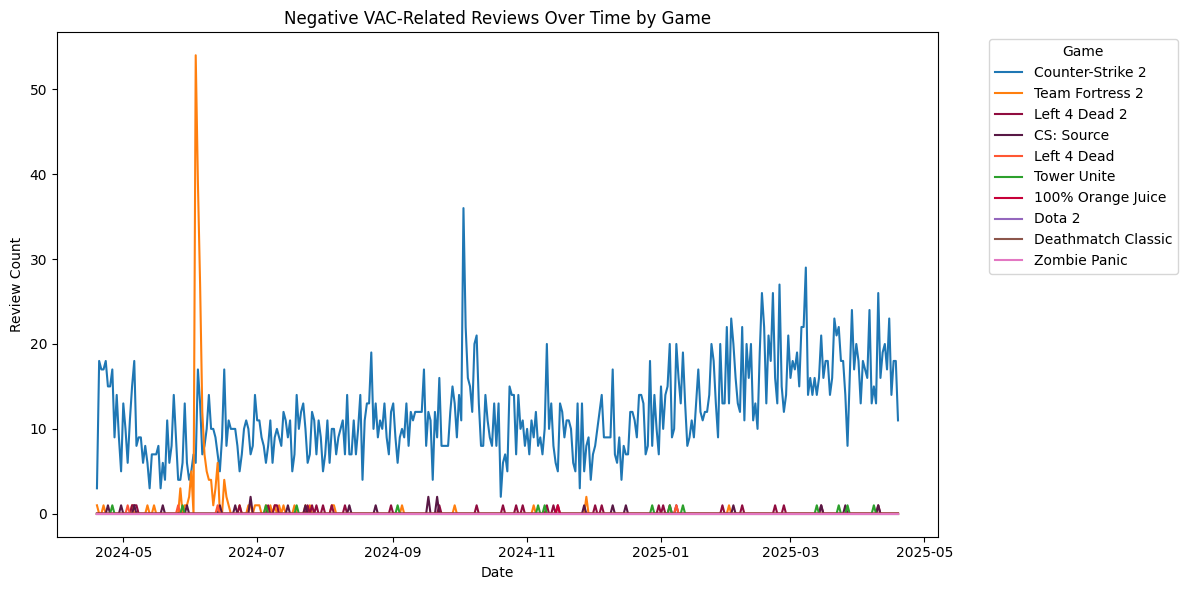

In [50]:
import matplotlib.pyplot as plt

custom_colors = {
    'Counter-Strike 2': '#1f77b4',
    'Team Fortress 2': '#ff7f0e',
    'Left 4 Dead 2': '#900C3F',
    'CS: Source': '#581845',
    'Left 4 Dead': '#FF5733',
    'Tower Unite': '#2ca02c',
    '100% Orange Juice': '#C70039',
    'Dota 2': '#9467bd',
    'Deathmatch Classic': '#8c564b',
    'Zombie Panic': '#e377c2'
}
# === Plotting: Time Series of Negative Reviews ===
negatives_by_date.plot(
    figsize=(12, 6),
    title="Negative VAC-Related Reviews Over Time by Game",
    color=[custom_colors[game] for game in negatives_by_date.columns]
)

plt.xlabel("Date")
plt.ylabel("Review Count")
plt.legend(title="Game", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Sentiment Count

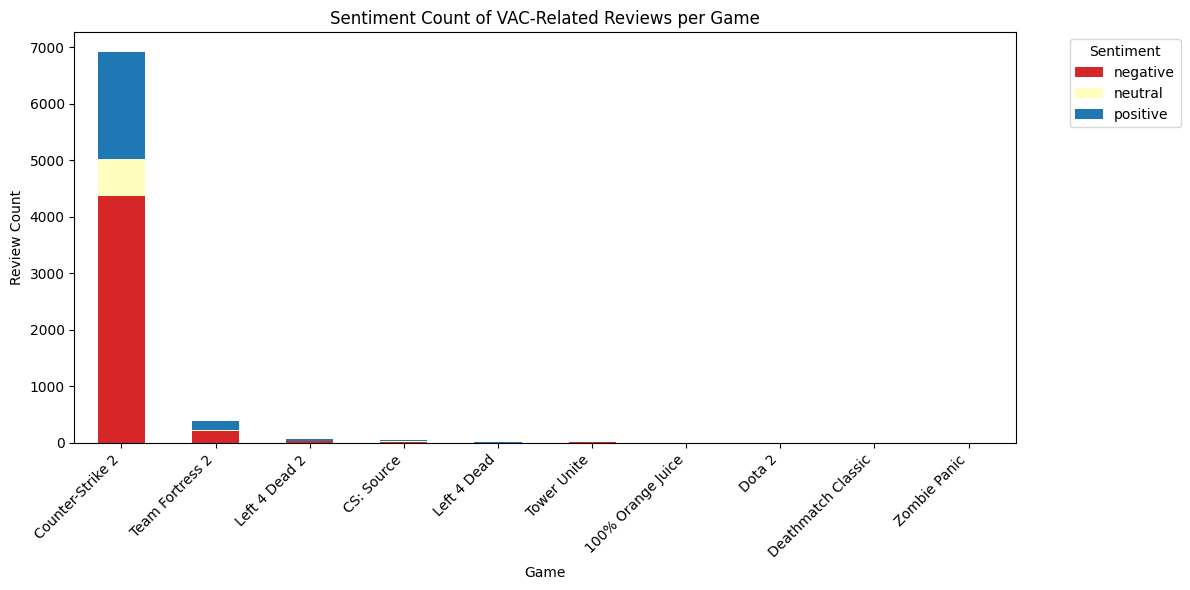

In [51]:
import matplotlib.pyplot as plt

sentiment_colors = {
    'positive': '#1f77b4',   # blue
    'neutral': '#FFFEBE',   # cream
    'negative': '#d62728'  # red
}

# Reorder columns to match color keys (if needed)
sentiment_counts = sentiment_counts[['negative', 'neutral', 'positive']]

# Plot sentiment counts
sentiment_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=[sentiment_colors[label] for label in sentiment_counts.columns],
    title='Sentiment Count of VAC-Related Reviews per Game'
)

plt.ylabel('Review Count')
plt.xlabel('Game')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




Sentiment Percentages

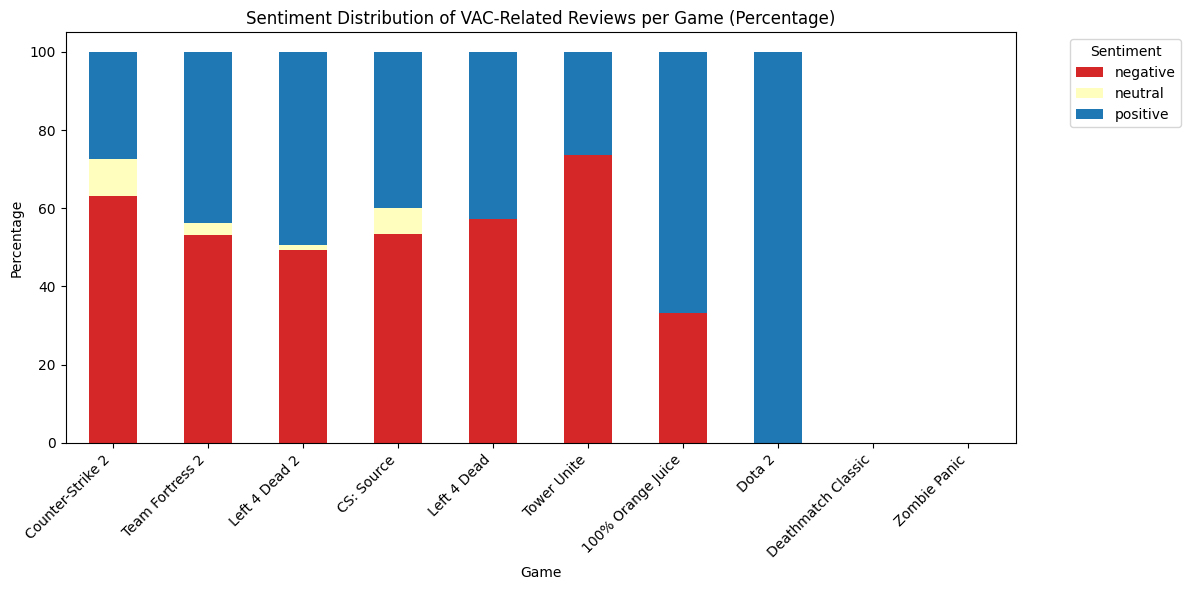

In [52]:
sentiment_percentages = sentiment_percentages[['negative', 'neutral', 'positive']]


# Plot sentiment percentages
sentiment_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=[sentiment_colors[label] for label in sentiment_percentages.columns],
    title='Sentiment Distribution of VAC-Related Reviews per Game (Percentage)'
)

plt.ylabel('Percentage')
plt.xlabel('Game')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Keyword Frequency Analysis

cheat: 2331
vac: 1569
cheater: 1543
cheating: 976
banned: 738
ban: 715
hacker: 518
rage: 439
hack: 273
aimbot: 124
wallhack: 63
spinbot: 44
script: 17
scripting: 1


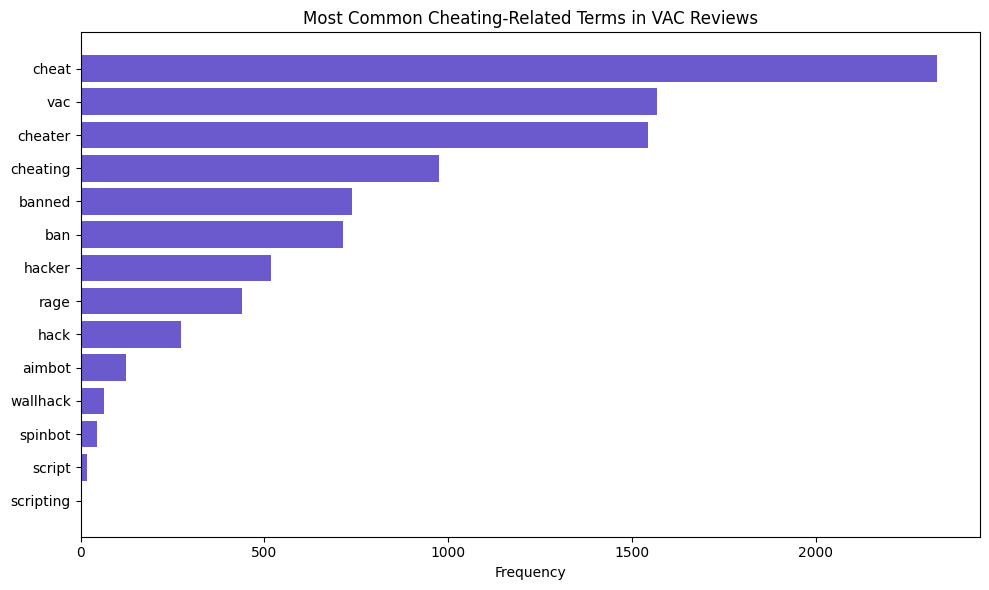

In [59]:
import re
from collections import Counter

keywords = [
    'vac', 'cheat', 'cheater', 'cheating', 'hack', 'hacker',
    'aimbot', 'wallhack', 'ban', 'banned', 'script', 'scripting', 'rage', 'spinbot'
]

# Convert review text to lowercase
all_reviews['text'] = all_reviews['text'].astype(str).str.lower()

# Count keyword occurrences
keyword_counter = Counter()

for text in all_reviews['text']:
    for kw in keywords:
        if re.search(rf'\b{kw}\b', text):
            keyword_counter[kw] += 1


# Show top N keywords
for word, count in keyword_counter.most_common():
    print(f"{word}: {count}")

import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame for plotting
keyword_df = pd.DataFrame(keyword_counter.items(), columns=['keyword', 'count'])
keyword_df = keyword_df.sort_values(by='count', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(keyword_df['keyword'], keyword_df['count'], color='slateblue')
plt.xlabel("Frequency")
plt.title("Most Common Cheating-Related Terms in VAC Reviews")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()


Playtime vs. Sentiment

label
negative    751.82
neutral     675.92
positive    808.77
Name: playtime_hours, dtype: float64


C:\Users\Austin\AppData\Local\Temp\ipykernel_23596\4201478909.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_reviews, x='label', y='playtime_hours', palette='pastel')


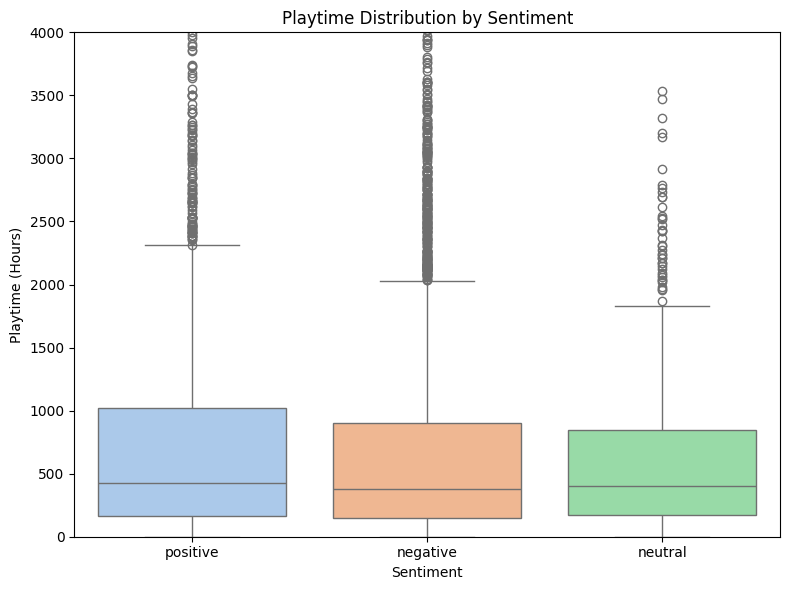

In [64]:
all_reviews['playtime_minutes']
all_reviews['playtime_hours'] = all_reviews['playtime_minutes'] / 60

# Group by sentiment and get average playtime
avg_playtime = all_reviews.groupby('label')['playtime_hours'].mean().round(2)
print(avg_playtime)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=all_reviews, x='label', y='playtime_hours', palette='pastel')
plt.ylim(0, 4000)
plt.title('Playtime Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Playtime (Hours)')
plt.tight_layout()
plt.show()
